## What is the most optimal skill to learn?

### Methodology:

#### 1. Group skills to determine median salary and likelihood of being in posting
#### 2. Visualize median salary vs percent skill demand

In [1]:
# Importing libraries

import ast
import pandas as pd 
import seaborn as sns 
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading data 

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
# European jobs filter and droping na values

european_countries = [
    'Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 
    'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Czech Republic', 
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 
    'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 
    'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 
    'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 
    'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 
    'Ukraine', 'United Kingdom', 'UK', 'Vatican City'
]

# Condition to meet
df_europe = df[df['job_country'].isin(european_countries)]

# Dropping na
df_europe = df_europe.dropna(subset=['salary_year_avg'])
df_europe_exploded = df_europe.explode('job_skills')
df_europe_exploded[['salary_year_avg', 'job_skills']].head(5)


,salary_year_avg,job_skills
212,157500.0,c
212,157500.0,r
212,157500.0,sql
212,157500.0,python
212,157500.0,aws


In [12]:
df_europe_skills = df_europe_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_europe_skills = df_europe_skills.rename(columns={'count':'skill_count', 'median':'median_salary'})

df_europe_skills

job_count = len(df_europe)

df_europe_skills['skill_percent'] = df_europe_skills['skill_count'] / job_count*100

df_europe_skills

skill_percent = 9

df_europe_skills_high_demand = df_europe_skills[df_europe_skills['skill_percent'] > skill_percent]

df_europe_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
python,1179,106439.50,55.144995
sql,1028,107719.75,48.082320
aws,511,131580.00,23.900842
spark,454,132040.00,21.234799
azure,376,101029.00,17.586529
tableau,324,105475.00,15.154350
excel,238,89100.00,11.131899
r,238,104984.00,11.131899
java,237,98283.00,11.085126


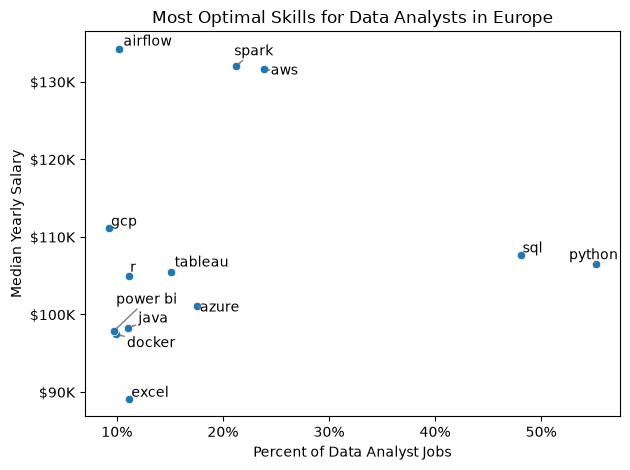

In [21]:
from adjustText import adjust_text
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df_europe_skills_high_demand,
    x='skill_percent',
    y='median_salary'
)

texts = []
for i, txt in enumerate(df_europe_skills_high_demand.index):
    texts.append(plt.text(df_europe_skills_high_demand['skill_percent'].iloc[i], df_europe_skills_high_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in Europe')

plt.tight_layout()
plt.show()